# Diagnóstico, interpretación acústica y proyección supervisada

Este notebook continúa el análisis **sin abrir los test finales** y mantiene congeladas las referencias de Sprint 3.

Responde tres preguntas:

1. ¿La variabilidad se concentra en actores, emociones o interacciones actor–emoción?
2. ¿Qué familias acústicas eGeMAPS aportan información útil y estable?
3. ¿Una proyección LDA regularizada mejora la media o reduce el desvío frente a la representación completa y PCA?

Los resultados completos se guardan en CSV. El notebook prioriza gráficos compactos, matrices de confusión normalizadas y resúmenes de media ± desvío.

## Ejecución

Los flags están desactivados por defecto para cargar artefactos ya calculados.

Orden recomendado:

1. `RUN_OOF_DIAGNOSTICS = True`
2. `RUN_FAMILY_ABLATIONS = True`
3. `RUN_LDA = True`

`RUN_LDA_WAV2VEC` queda separado para permitir omitir wav2vec en máquinas con menos recursos. Por defecto está habilitado cuando se ejecuta LDA.

In [1]:
from __future__ import annotations

import sys
from functools import partial
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

from src.evaluation.diagnostics import (
    build_oof_diagnostics,
    compute_actor_class_recall,
    compute_actor_metrics,
    compute_fold_metrics_from_predictions,
)
from src.evaluation.reporting import (
    save_cv_results,
    summarize_cv_results,
    upsert_cv_results,
)
from src.experiments.baselines import make_model_factory
from src.experiments.cross_validation import run_cv
from src.experiments.diagnostics_interpretability import (
    run_family_ablations,
    run_lda_grid,
)
from src.feature_selection.supervised_projection import (
    build_lda_linear_probe,
    get_lda_fold_metadata,
)
from src.features.egemaps_families import (
    FAMILY_LABELS,
    aggregate_family_importance,
    normalize_family_importance,
)
from src.features.feature_store import load_representation
from src.utils.config import get_config, resolve_path
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

sns.set_context("notebook")
sns.set_style("whitegrid")

cfg = get_config()
set_global_seed(cfg.seed)

metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)
representations = {
    "egemaps": load_representation("egemaps", cfg.paths.features_dir),
    "wav2vec": load_representation("wav2vec", cfg.paths.features_dir),
}

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
CV_RESULTS_PATH = REPORTS_DIR / "cv_results.csv"
FEATURE_SELECTION_PATH = REPORTS_DIR / "feature_selection.csv"
OOF_PATH = REPORTS_DIR / "oof_predictions_diagnostics.csv"
FAMILY_RESULTS_PATH = REPORTS_DIR / "egemaps_family_results.csv"
FAMILY_IMPORTANCE_PATH = REPORTS_DIR / "egemaps_family_importance.csv"

RUN_OOF_DIAGNOSTICS = True
RUN_FAMILY_ABLATIONS = True
RUN_LDA = True
RUN_LDA_WAV2VEC = True

PROTOCOL = "speaker_independent"
PRIMARY_TARGET = "emotion_original"
FAMILY_TARGETS = ("emotion_original", "emotion_quadrant")
LDA_TARGETS = (
    "emotion_original",
    "emotion_quadrant",
    "emotion_original_eval_quadrant",
)
EMOTION_ORDER = [
    "angry", "calm", "disgust", "fearful",
    "happy", "neutral", "sad", "surprised",
]


def read_csv_or_empty(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


cv_results = read_csv_or_empty(CV_RESULTS_PATH)
feature_selection = read_csv_or_empty(FEATURE_SELECTION_PATH)
oof_cache = read_csv_or_empty(OOF_PATH)
family_results = read_csv_or_empty(FAMILY_RESULTS_PATH)

print(f"metadata: {metadata.shape}")
print(f"splits: {splits.shape}")
print(f"cv_results: {cv_results.shape if not cv_results.empty else 'pendiente'}")
print(f"feature_selection: {feature_selection.shape if not feature_selection.empty else 'pendiente'}")

2026-06-30 15:15:57 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.
2026-06-30 15:15:57 | INFO     | src.features.feature_store | Cargado 'wav2vec': 1440 muestras, 768 features.
metadata: (1440, 23)
splits: (1440, 3)
cv_results: (195, 25)
feature_selection: (5280, 11)


## 1. Referencias congeladas de Sprint 3

Se conservan dos referencias:

- **Principal:** wav2vec mean + Logistic Regression.
- **Interpretable:** eGeMAPSv02 + Logistic Regression.

El gráfico evita reabrir toda la matriz experimental y muestra solamente estas referencias bajo speaker-independent.

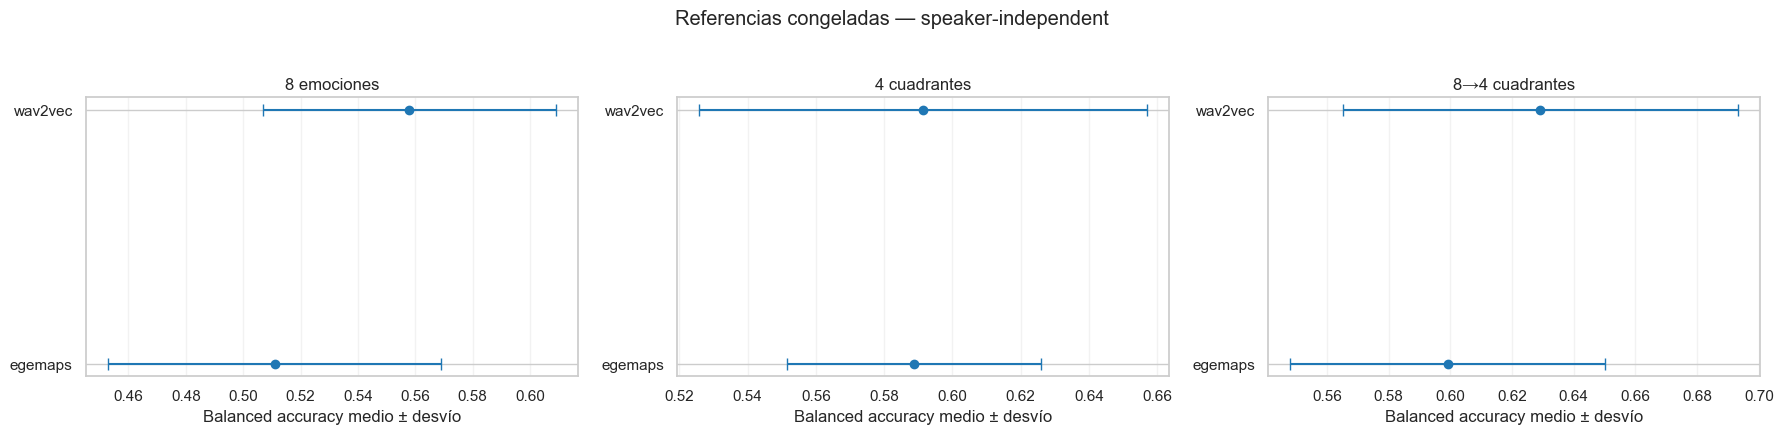

In [2]:
TARGET_LABELS = {
    "emotion_original": "8 emociones",
    "emotion_quadrant": "4 cuadrantes",
    "emotion_original_eval_quadrant": "8→4 cuadrantes",
}

if cv_results.empty:
    print("Falta reports/cv_results.csv. Ejecute primero el notebook de Sprint 3.")
else:
    summary = summarize_cv_results(cv_results)
    reference = summary.query(
        "protocol == @PROTOCOL and "
        "model == 'logistic_regression' and "
        "refinement == 'none' and "
        "representation in ['egemaps', 'wav2vec']"
    ).copy()

    targets = [target for target in TARGET_LABELS if target in set(reference["target"])]
    fig, axes = plt.subplots(1, len(targets), figsize=(6 * len(targets), 4.2), squeeze=False)
    for ax, target in zip(axes.ravel(), targets):
        data = reference.query("target == @target").sort_values("balanced_accuracy_mean")
        ax.errorbar(
            data["balanced_accuracy_mean"],
            data["representation"],
            xerr=data["balanced_accuracy_std"],
            fmt="o",
            capsize=4,
        )
        ax.set_title(TARGET_LABELS[target])
        ax.set_xlabel("Balanced accuracy medio ± desvío")
        ax.grid(axis="x", alpha=0.25)
    fig.suptitle("Referencias congeladas — speaker-independent", y=1.03)
    plt.tight_layout()
    plt.show()

## 2. Diagnóstico visual de la varianza

Las predicciones se obtienen mediante los folds persistidos de development. Cada audio aparece una sola vez como validación OOF para cada configuración.

El diagnóstico se concentra en:

- distribución del macro F1 por actor;
- recall actor × emoción;
- estabilidad del recall de cada emoción entre actores;
- comportamiento por outer fold.

In [3]:
EXPERIMENT_COLUMNS = [
    "representation", "protocol", "target", "model", "refinement"
]


def config_mask(frame: pd.DataFrame, config: dict) -> pd.Series:
    mask = pd.Series(True, index=frame.index)
    for column, value in config.items():
        mask &= frame[column].astype(str).eq(str(value))
    return mask


def collect_oof(config: dict) -> pd.DataFrame:
    representation_name = config["representation"]
    refinement = config["refinement"]

    if refinement == "none":
        factory = make_model_factory(
            model_name="logistic_regression",
            model_config=cfg.models.logistic_regression,
            seed=cfg.seed,
        )
        metadata_fn = None
    elif refinement == "lda_shrinkage":
        factory = partial(
            build_lda_linear_probe,
            logistic_regression_params=cfg.models.logistic_regression,
            seed=cfg.seed,
            shrinkage=cfg.post_sprint3.lda.shrinkage,
        )
        metadata_fn = get_lda_fold_metadata
    else:
        raise ValueError(f"Refinamiento OOF no soportado: {refinement}")

    output = run_cv(
        pipeline_factory=factory,
        representation=representations[representation_name],
        metadata=metadata,
        splits=splits,
        target_col=config["target"],
        representation_name=representation_name,
        model_name="logistic_regression",
        refinement=refinement,
        n_folds=cfg.splits.cv_folds,
        fitted_metadata_fn=metadata_fn,
    )
    predictions = output["predictions"].copy()
    for column, value in config.items():
        predictions[column] = value
    return predictions


def ensure_oof(configs: list[dict], allow_compute: bool) -> pd.DataFrame:
    global oof_cache
    frames = [oof_cache] if not oof_cache.empty else []

    for config in configs:
        available = (
            not oof_cache.empty
            and config_mask(oof_cache, config).any()
        )
        if available:
            continue
        if not allow_compute:
            print("OOF pendiente:", config)
            continue
        print("Calculando OOF:", config)
        frames.append(collect_oof(config))

    if not frames:
        return pd.DataFrame()

    result = pd.concat(frames, ignore_index=True, sort=False)
    result = result.drop_duplicates(
        subset=EXPERIMENT_COLUMNS + ["file_id"],
        keep="last",
    )
    OOF_PATH.parent.mkdir(parents=True, exist_ok=True)
    result.to_csv(OOF_PATH, index=False)
    oof_cache = result
    return result


baseline_configs = [
    {
        "representation": representation,
        "protocol": PROTOCOL,
        "target": PRIMARY_TARGET,
        "model": "logistic_regression",
        "refinement": "none",
    }
    for representation in ("egemaps", "wav2vec")
]

oof_cache = ensure_oof(baseline_configs, allow_compute=RUN_OOF_DIAGNOSTICS)

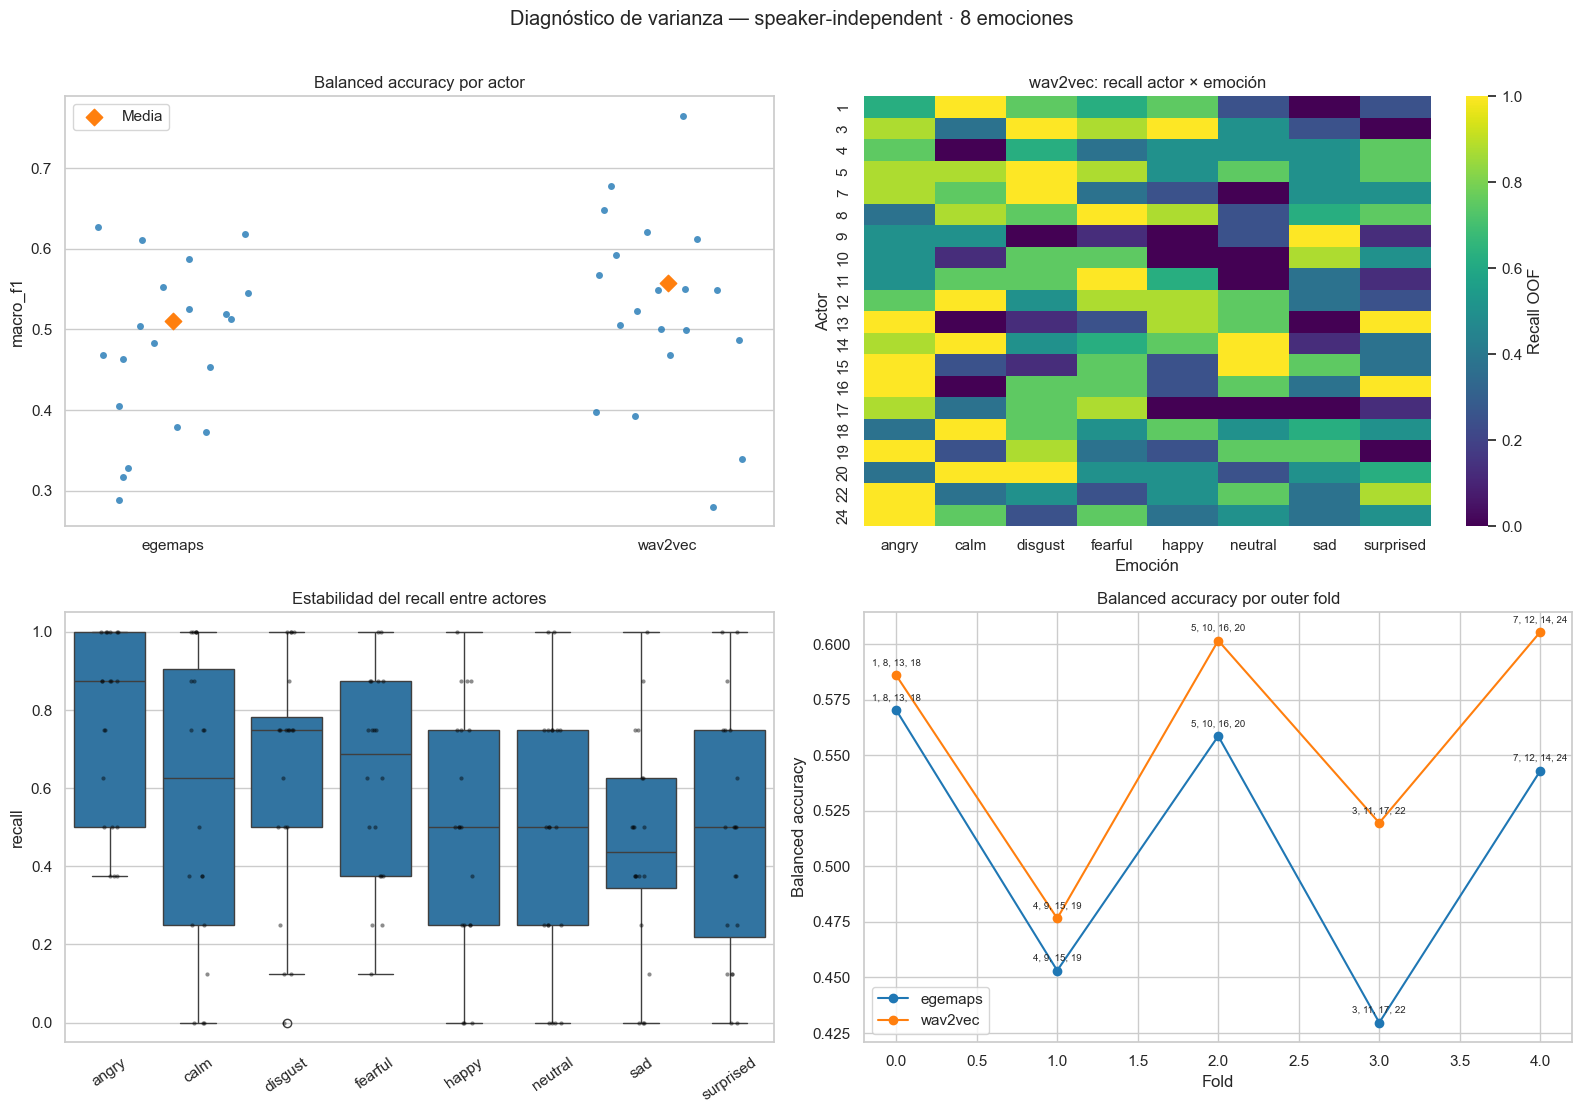

,balanced_accuracy_actor_mean,balanced_accuracy_actor_std,worst_actor,best_actor
representation,,,,
egemaps,0.511,0.102,0.344,0.672
wav2vec,0.558,0.106,0.312,0.766


In [4]:
if oof_cache.empty:
    print("Active RUN_OOF_DIAGNOSTICS para generar el diagnóstico por actor.")
else:
    baseline_oof = oof_cache.query(
        "protocol == @PROTOCOL and target == @PRIMARY_TARGET and "
        "model == 'logistic_regression' and refinement == 'none'"
    ).copy()

    diagnostic_frames = []
    for representation_name, group in baseline_oof.groupby("representation", observed=True):
        diagnostic = build_oof_diagnostics(group.copy(), metadata)
        diagnostic["representation"] = representation_name
        diagnostic_frames.append(diagnostic)
    diagnostics = pd.concat(diagnostic_frames, ignore_index=True)

    actor_metrics = compute_actor_metrics(diagnostics)
    actor_class = compute_actor_class_recall(diagnostics)
    fold_metrics = compute_fold_metrics_from_predictions(diagnostics)

    actor_metrics.to_csv(REPORTS_DIR / "actor_diagnostics.csv", index=False)

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    sns.stripplot(
        data=actor_metrics,
        x="representation",
        y="macro_f1",
        jitter=0.16,
        alpha=0.8,
        ax=axes[0, 0],
    )
    means = actor_metrics.groupby("representation", observed=True)["balanced_accuracy"].mean()
    axes[0, 0].scatter(range(len(means)), means.values, marker="D", s=70, label="Media")
    axes[0, 0].set_title("Balanced accuracy por actor")
    axes[0, 0].set_xlabel("")
    axes[0, 0].legend()

    primary_matrix = (
        actor_class.query("representation == 'wav2vec'")
        .pivot(index="actor_id", columns="target_class", values="recall")
        .reindex(columns=EMOTION_ORDER)
    )
    sns.heatmap(
        primary_matrix,
        vmin=0,
        vmax=1,
        cmap="viridis",
        ax=axes[0, 1],
        cbar_kws={"label": "Recall OOF"},
    )
    axes[0, 1].set_title("wav2vec: recall actor × emoción")
    axes[0, 1].set_xlabel("Emoción")
    axes[0, 1].set_ylabel("Actor")

    recall_data = actor_class.query("representation == 'wav2vec'").copy()
    recall_data["target_class"] = pd.Categorical(
        recall_data["target_class"], categories=EMOTION_ORDER, ordered=True
    )
    sns.boxplot(
        data=recall_data,
        x="target_class",
        y="recall",
        ax=axes[1, 0],
    )
    sns.stripplot(
        data=recall_data,
        x="target_class",
        y="recall",
        color="black",
        alpha=0.45,
        size=3,
        ax=axes[1, 0],
    )
    axes[1, 0].tick_params(axis="x", rotation=35)
    axes[1, 0].set_title("Estabilidad del recall entre actores")
    axes[1, 0].set_xlabel("")

    for representation_name, group in fold_metrics.groupby("representation", observed=True):
        axes[1, 1].plot(group["fold"], group["balanced_accuracy"], marker="o", label=representation_name)
        for _, row in group.iterrows():
            axes[1, 1].annotate(
                row.get("validation_actors", ""),
                (row["fold"], row["balanced_accuracy"]),
                textcoords="offset points",
                xytext=(0, 7),
                ha="center",
                fontsize=7,
            )
    axes[1, 1].set_title("Balanced accuracy por outer fold")
    axes[1, 1].set_xlabel("Fold")
    axes[1, 1].set_ylabel("Balanced accuracy")
    axes[1, 1].legend()

    fig.suptitle("Diagnóstico de varianza — speaker-independent · 8 emociones", y=1.01)
    plt.tight_layout()
    plt.show()

    compact = (
        actor_metrics.groupby("representation", observed=True)
        .agg(
            balanced_accuracy_actor_mean=("balanced_accuracy", "mean"),
            balanced_accuracy_actor_std=("balanced_accuracy", "std"),
            worst_actor=("balanced_accuracy", "min"),
            best_actor=("balanced_accuracy", "max"),
        )
        .round(3)
    )
    display(compact)

## 3. Interpretación de eGeMAPS por familias acústicas

Las 88 features se agrupan en siete familias. La comparación principal utiliza la **importancia media por feature**, evitando favorecer automáticamente a familias más numerosas.

La estabilidad se comunica como media ± desvío entre outer folds, sin agregar nuevos índices de ranking.

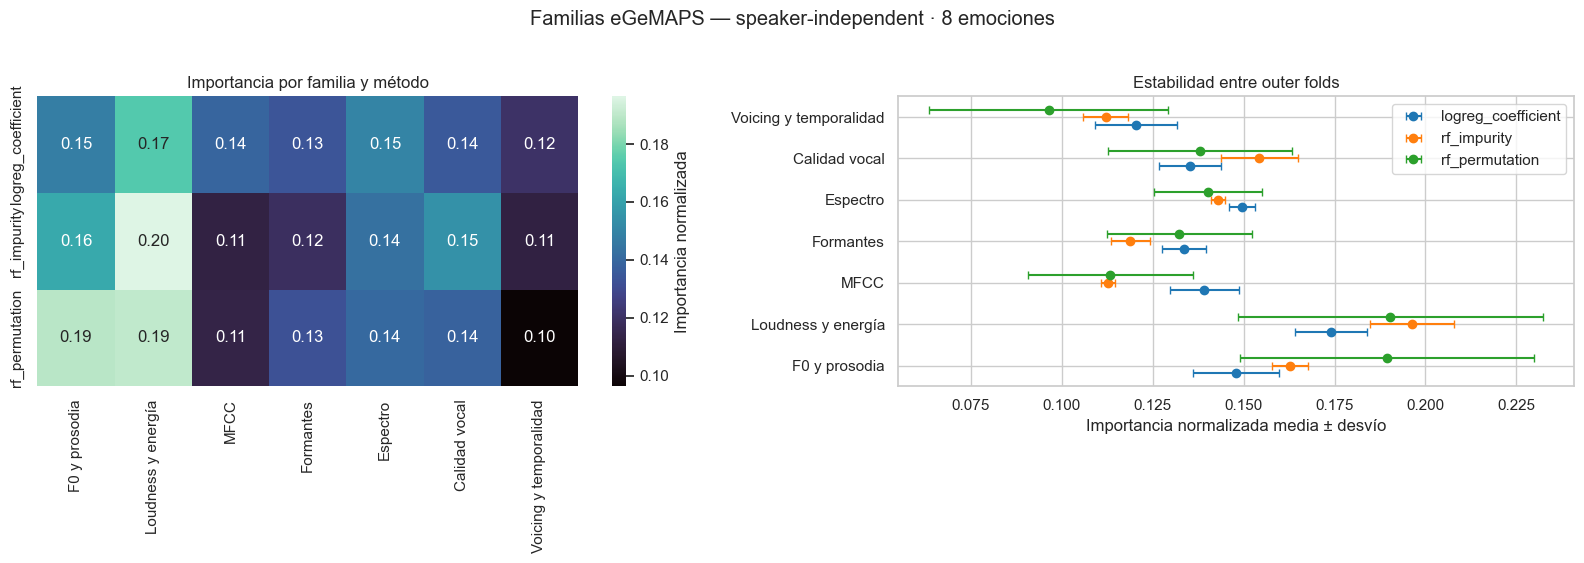

In [5]:
if feature_selection.empty:
    print("Falta reports/feature_selection.csv. Ejecute feature importance en el notebook 03.")
else:
    importance_source = feature_selection.query(
        "protocol == @PROTOCOL and "
        "target in ['emotion_original', 'emotion_quadrant'] and "
        "method in ['logreg_coefficient', 'rf_impurity', 'rf_permutation']"
    ).copy()

    family_importance = aggregate_family_importance(
        importance_source,
        feature_names=[column for column in representations["egemaps"].columns if column != "file_id"],
    )
    family_importance = normalize_family_importance(family_importance)
    family_importance.to_csv(FAMILY_IMPORTANCE_PATH, index=False)

    focus = family_importance.query("target == 'emotion_original'").copy()
    family_order = list(FAMILY_LABELS.values())
    method_order = ["logreg_coefficient", "rf_impurity", "rf_permutation"]

    heatmap_data = (
        focus.groupby(["method", "family_label"], observed=True)["importance_normalized"]
        .mean()
        .unstack("family_label")
        .reindex(index=method_order, columns=family_order)
    )

    stability = (
        focus.groupby(["method", "family_label"], observed=True)["importance_normalized"]
        .agg(["mean", "std"])
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="mako",
        ax=axes[0],
        cbar_kws={"label": "Importancia normalizada"},
    )
    axes[0].set_title("Importancia por familia y método")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    offsets = np.linspace(-0.18, 0.18, len(method_order))
    y = np.arange(len(family_order))
    for offset, method in zip(offsets, method_order):
        group = stability.query("method == @method").set_index("family_label").reindex(family_order)
        axes[1].errorbar(
            group["mean"],
            y + offset,
            xerr=group["std"].fillna(0),
            fmt="o",
            capsize=3,
            label=method,
        )
    axes[1].set_yticks(y, family_order)
    axes[1].set_xlabel("Importancia normalizada media ± desvío")
    axes[1].set_title("Estabilidad entre outer folds")
    axes[1].legend()

    fig.suptitle("Familias eGeMAPS — speaker-independent · 8 emociones", y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Ablaciones por familia

Dos experimentos validan la interpretación:

- **Family-only:** cuánta información contiene una familia por sí sola.
- **Leave-one-family-out:** cuánto cambia el modelo al eliminar esa familia.

La línea vertical en cero representa eGeMAPS completo.

In [6]:
if RUN_FAMILY_ABLATIONS:
    output = run_family_ablations(
        egemaps=representations["egemaps"],
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        protocols=(PROTOCOL,),
        targets=FAMILY_TARGETS,
        n_folds=cfg.splits.cv_folds,
    )
    family_results = output["fold_results"]
    family_results.to_csv(FAMILY_RESULTS_PATH, index=False)
elif FAMILY_RESULTS_PATH.exists():
    family_results = pd.read_csv(FAMILY_RESULTS_PATH)
else:
    print("Active RUN_FAMILY_ABLATIONS para ejecutar las ablaciones.")

2026-06-30 15:15:59 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_original_speaker_independent_all_features ===
2026-06-30 15:15:59 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.5560 | BalAcc=0.5703 | UAR=0.5703 | Acc=0.5583
2026-06-30 15:15:59 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.4504 | BalAcc=0.4531 | UAR=0.4531 | Acc=0.4625
2026-06-30 15:15:59 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.5484 | BalAcc=0.5586 | UAR=0.5586 | Acc=0.5583
2026-06-30 15:15:59 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.4178 | BalAcc=0.4297 | UAR=0.4297 | Acc=0.4375
2026-06-30 15:15:59 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.5433 | BalAcc=0.5430 | UAR=0.5430 | Acc=0.5542
2026-06-30 15:15:59 | INFO     | src.experiments.cross_validation | === egemaps_logistic_regression_emotion_original_speaker_independent_all_features — balanced_accuracy 0.5109 ± 0.0579 ===
2026-06-30 15:15:59 | INFO 

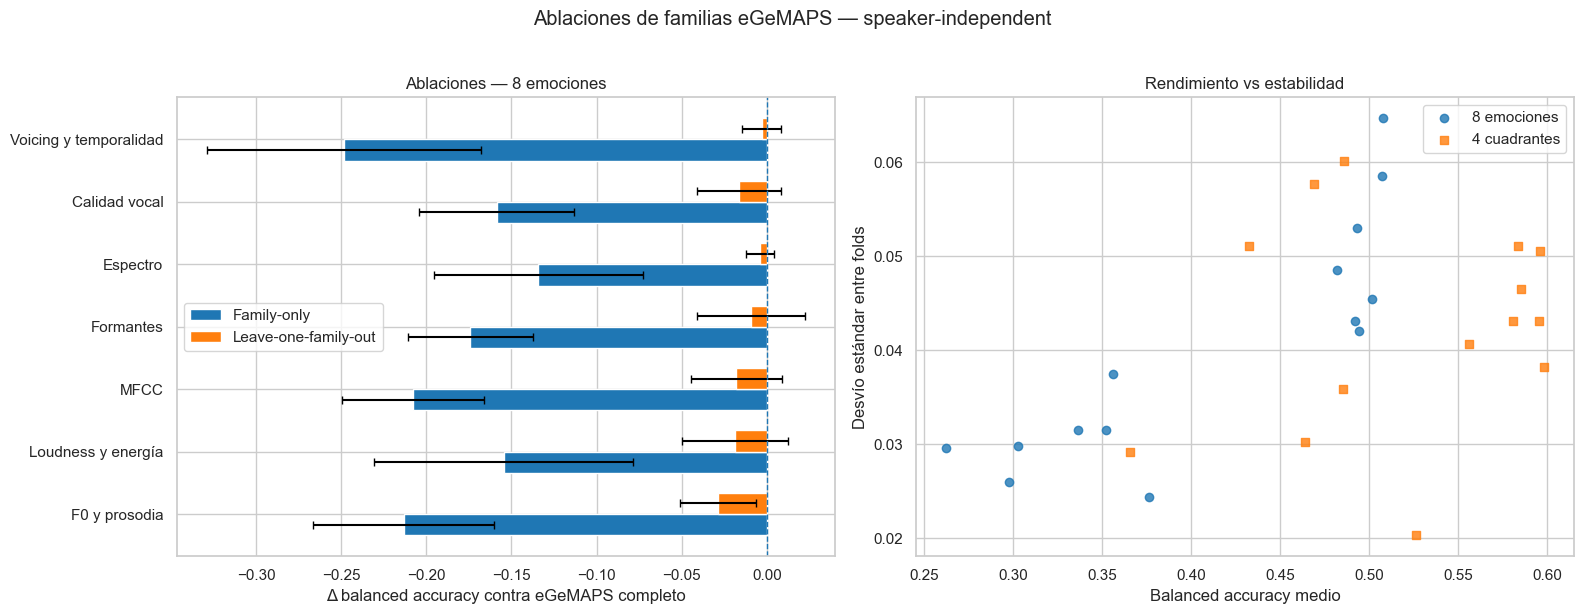

In [7]:
if not family_results.empty:
    ablation_summary = (
        family_results.groupby(
            ["target", "experiment", "family", "family_label"],
            observed=True,
        )
        .agg(
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            balanced_accuracy_std=("balanced_accuracy", "std"),
            delta_mean=("delta_balanced_accuracy", "mean"),
            delta_std=("delta_balanced_accuracy", "std"),
        )
        .reset_index()
    )

    focus = ablation_summary.query(
        "target == 'emotion_original' and experiment != 'all_features'"
    ).copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    families = list(FAMILY_LABELS.values())
    y = np.arange(len(families))
    width = 0.34
    for offset, experiment, label in (
        (-width / 2, "family_only", "Family-only"),
        (width / 2, "leave_one_family_out", "Leave-one-family-out"),
    ):
        group = focus.query("experiment == @experiment").set_index("family_label").reindex(families)
        axes[0].barh(
            y + offset,
            group["delta_mean"],
            xerr=group["delta_std"].fillna(0),
            height=width,
            label=label,
            capsize=3,
        )
    axes[0].axvline(0, linestyle="--", linewidth=1)
    axes[0].set_yticks(y, families)
    axes[0].set_xlabel("Δ balanced accuracy contra eGeMAPS completo")
    axes[0].set_title("Ablaciones — 8 emociones")
    axes[0].legend()

    scatter = ablation_summary.query("experiment != 'all_features'").copy()
    markers = {"emotion_original": "o", "emotion_quadrant": "s"}
    for target, group in scatter.groupby("target", observed=True):
        axes[1].scatter(
            group["balanced_accuracy_mean"],
            group["balanced_accuracy_std"],
            marker=markers.get(target, "o"),
            alpha=0.8,
            label=TARGET_LABELS.get(target, target),
        )
    axes[1].set_xlabel("Balanced accuracy medio")
    axes[1].set_ylabel("Desvío estándar entre folds")
    axes[1].set_title("Rendimiento vs estabilidad")
    axes[1].legend()

    fig.suptitle("Ablaciones de familias eGeMAPS — speaker-independent", y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Proyección supervisada simple

La proyección implementada es:

```text
StandardScaler → LDA regularizada → Logistic Regression
```

LDA utiliza scores discriminantes ajustados exclusivamente con outer train y produce `n_clases - 1` dimensiones. Esto permite aplicar shrinkage también sobre wav2vec, aunque su costo sigue siendo mayor que en eGeMAPS.

In [8]:
if RUN_LDA:
    lda_representations = ("egemaps", "wav2vec") if RUN_LDA_WAV2VEC else ("egemaps",)
    output = run_lda_grid(
        representations=representations,
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        representation_names=lda_representations,
        protocols=(PROTOCOL,),
        targets=LDA_TARGETS,
        shrinkage=cfg.post_sprint3.lda.shrinkage,
        n_folds=cfg.splits.cv_folds,
    )
    cv_results = upsert_cv_results(cv_results, output["fold_results"])
    save_cv_results(cv_results, CV_RESULTS_PATH)
elif CV_RESULTS_PATH.exists():
    cv_results = pd.read_csv(CV_RESULTS_PATH)

2026-06-30 15:16:07 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_original_speaker_independent_lda_shrinkage ===
2026-06-30 15:16:07 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.5603 | BalAcc=0.5664 | UAR=0.5664 | Acc=0.5625
2026-06-30 15:16:07 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.4830 | BalAcc=0.4844 | UAR=0.4844 | Acc=0.4875
2026-06-30 15:16:07 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.5329 | BalAcc=0.5430 | UAR=0.5430 | Acc=0.5500
2026-06-30 15:16:08 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.4481 | BalAcc=0.4570 | UAR=0.4570 | Acc=0.4708
2026-06-30 15:16:08 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.5080 | BalAcc=0.5117 | UAR=0.5117 | Acc=0.5208
2026-06-30 15:16:08 | INFO     | src.experiments.cross_validation | === egemaps_logistic_regression_emotion_original_speaker_independent_lda_shrinkage — balanced_accuracy 0.5125 ± 0.0392 ===
2026-06-30 15:16:08 | INF

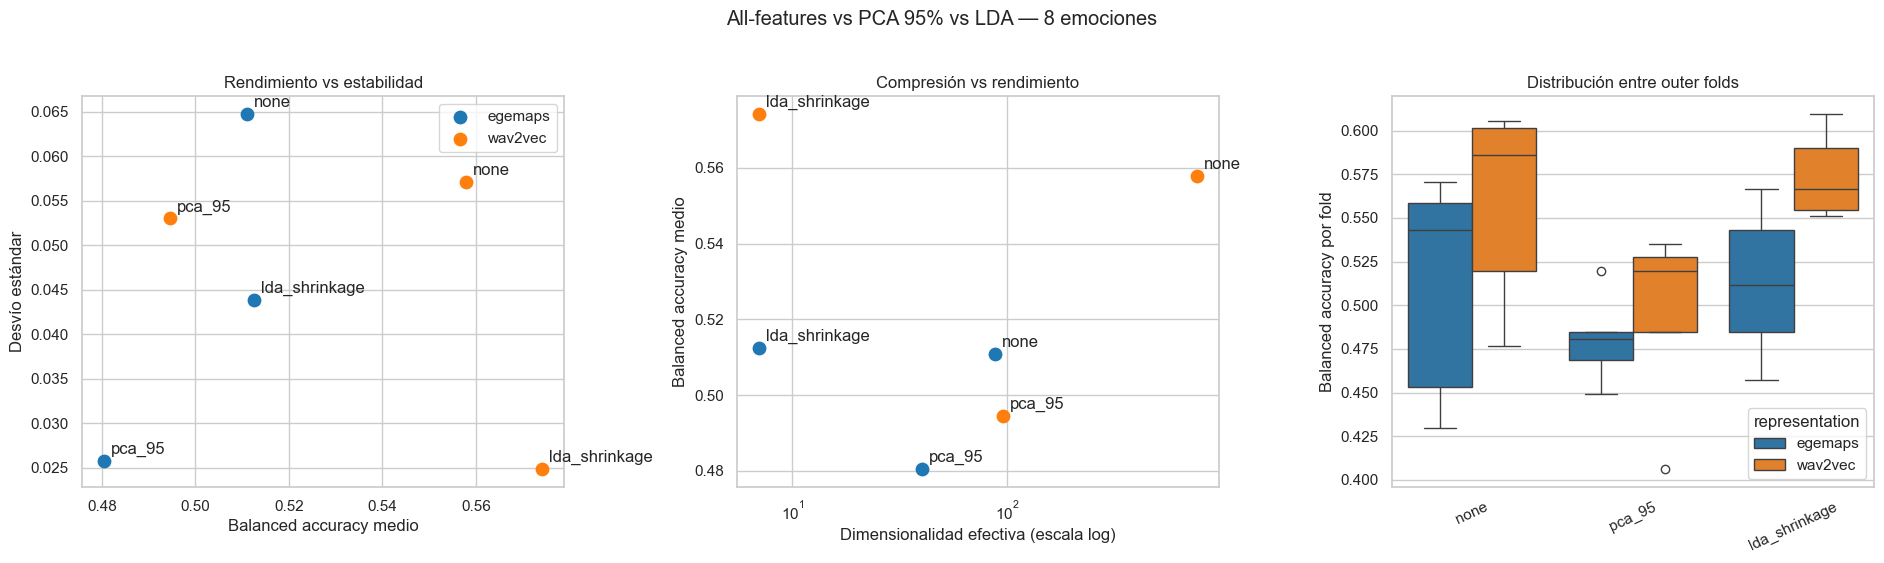

In [9]:
if cv_results.empty:
    print("No hay resultados de CV para comparar.")
else:
    comparison = cv_results.query(
        "protocol == @PROTOCOL and "
        "model == 'logistic_regression' and "
        "refinement in ['none', 'pca_95', 'lda_shrinkage']"
    ).copy()

    if comparison.empty:
        print("No hay resultados all-features/PCA/LDA disponibles.")
    else:
        comparison_summary = (
            comparison.groupby(
                ["representation", "target", "refinement"],
                observed=True,
            )
            .agg(
                balanced_accuracy_mean=("balanced_accuracy", "mean"),
                balanced_accuracy_std=("balanced_accuracy", "std"),
                n_features_mean=("n_features", "mean"),
            )
            .reset_index()
        )

        focus_summary = comparison_summary.query("target == @PRIMARY_TARGET").copy()
        focus_folds = comparison.query("target == @PRIMARY_TARGET").copy()

        fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
        for representation_name, group in focus_summary.groupby("representation", observed=True):
            axes[0].scatter(
                group["balanced_accuracy_mean"],
                group["balanced_accuracy_std"],
                s=80,
                label=representation_name,
            )
            for _, row in group.iterrows():
                axes[0].annotate(row["refinement"], (row["balanced_accuracy_mean"], row["balanced_accuracy_std"]), xytext=(5, 5), textcoords="offset points")
        axes[0].set_xlabel("Balanced accuracy medio")
        axes[0].set_ylabel("Desvío estándar")
        axes[0].set_title("Rendimiento vs estabilidad")
        axes[0].legend()

        for representation_name, group in focus_summary.groupby("representation", observed=True):
            axes[1].scatter(
                group["n_features_mean"],
                group["balanced_accuracy_mean"],
                s=80,
                label=representation_name,
            )
            for _, row in group.iterrows():
                axes[1].annotate(row["refinement"], (row["n_features_mean"], row["balanced_accuracy_mean"]), xytext=(5, 5), textcoords="offset points")
        axes[1].set_xscale("log")
        axes[1].set_xlabel("Dimensionalidad efectiva (escala log)")
        axes[1].set_ylabel("Balanced accuracy medio")
        axes[1].set_title("Compresión vs rendimiento")

        sns.boxplot(
            data=focus_folds,
            x="refinement",
            y="balanced_accuracy",
            hue="representation",
            ax=axes[2],
        )
        axes[2].set_xlabel("")
        axes[2].set_ylabel("Balanced accuracy por fold")
        axes[2].set_title("Distribución entre outer folds")
        axes[2].tick_params(axis="x", rotation=25)

        fig.suptitle("All-features vs PCA 95% vs LDA — 8 emociones", y=1.02)
        plt.tight_layout()
        plt.show()

## 6. Matrices de confusión: baseline vs LDA

Las matrices se normalizan por clase verdadera y se construyen con predicciones OOF. La tercera matriz representa `LDA − baseline`.

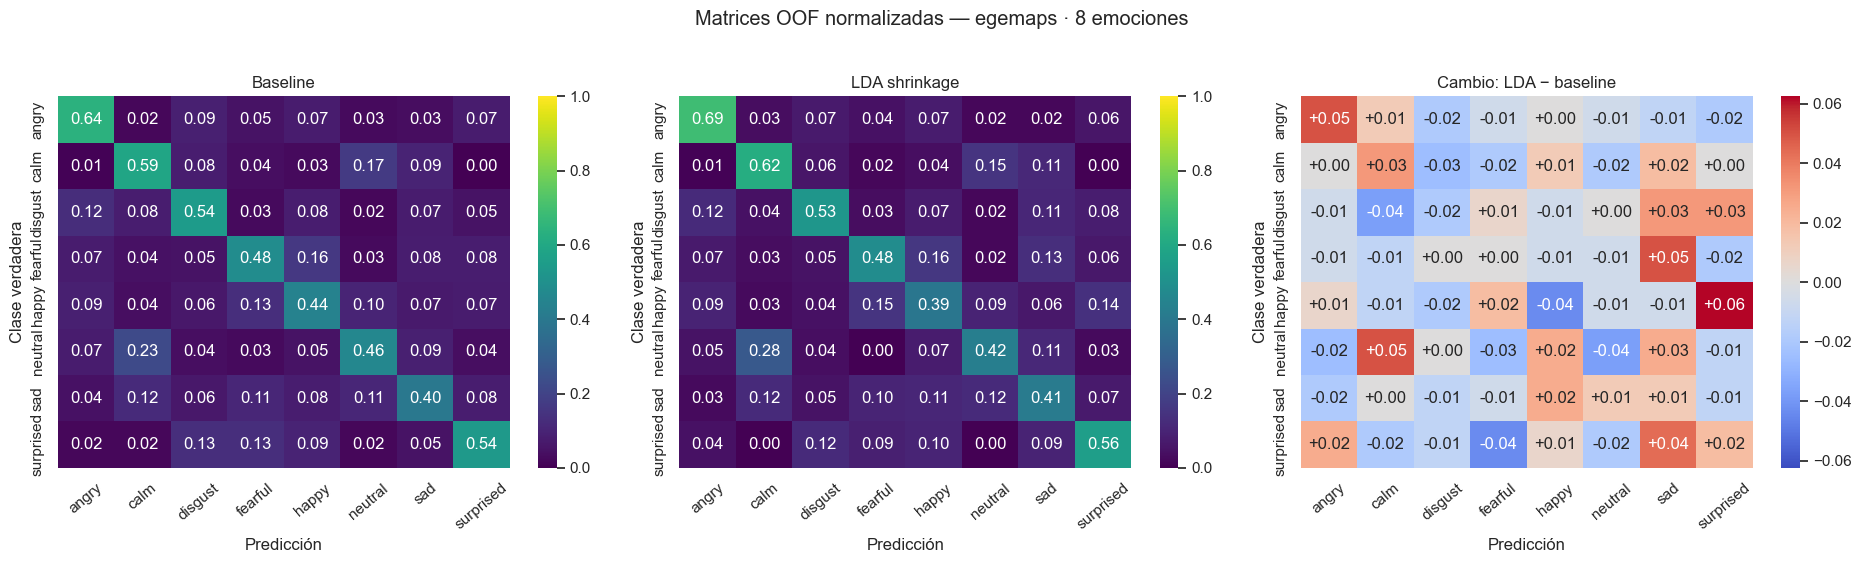

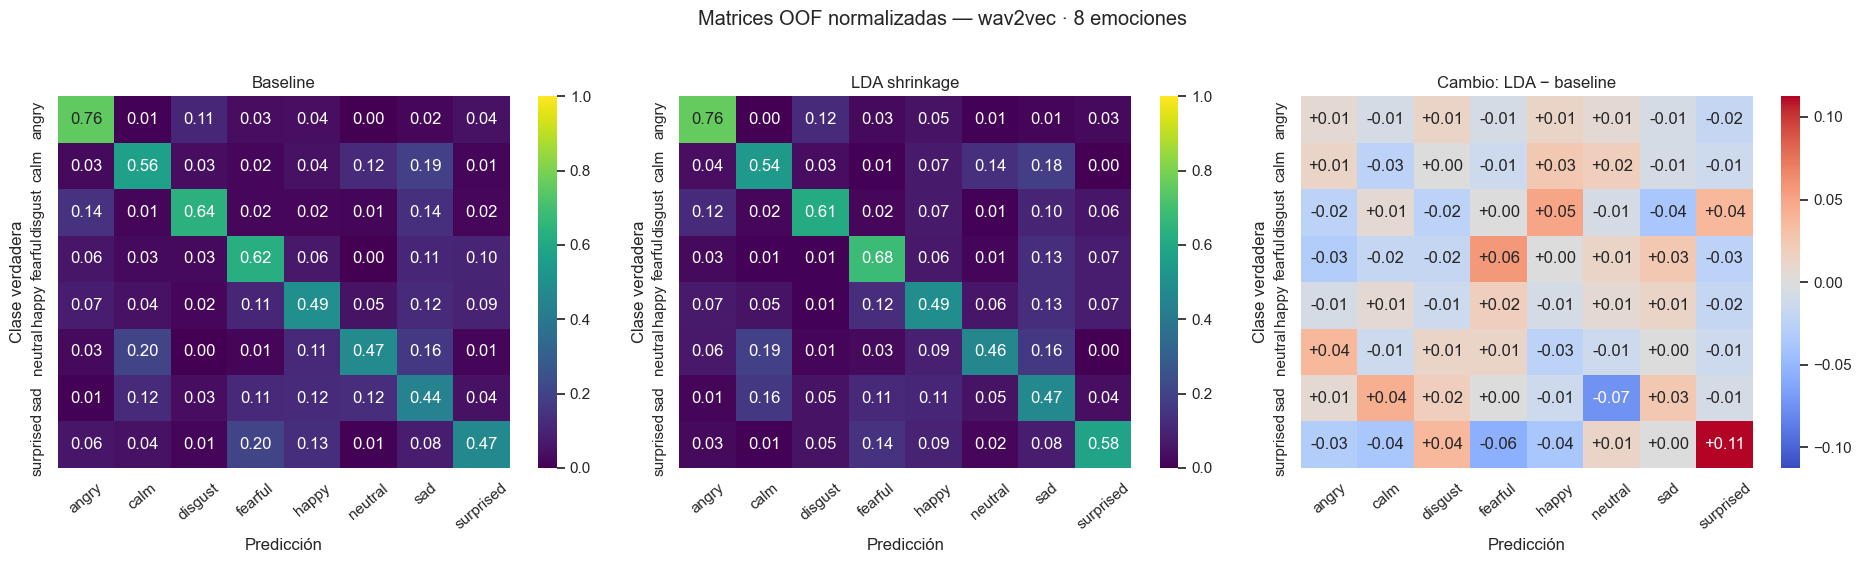

In [10]:
lda_configs = [
    {
        "representation": representation,
        "protocol": PROTOCOL,
        "target": PRIMARY_TARGET,
        "model": "logistic_regression",
        "refinement": "lda_shrinkage",
    }
    for representation in (("egemaps", "wav2vec") if RUN_LDA_WAV2VEC else ("egemaps",))
]

oof_cache = ensure_oof(
    baseline_configs + lda_configs,
    allow_compute=RUN_OOF_DIAGNOSTICS,
)


def normalized_cm(frame: pd.DataFrame, labels: list[str]) -> np.ndarray:
    return confusion_matrix(
        frame["y_true"],
        frame["y_pred"],
        labels=labels,
        normalize="true",
    )


for representation_name in ["egemaps", "wav2vec"]:
    baseline_config = {
        "representation": representation_name,
        "protocol": PROTOCOL,
        "target": PRIMARY_TARGET,
        "model": "logistic_regression",
        "refinement": "none",
    }
    lda_config = {**baseline_config, "refinement": "lda_shrinkage"}

    baseline = oof_cache.loc[config_mask(oof_cache, baseline_config)] if not oof_cache.empty else pd.DataFrame()
    lda = oof_cache.loc[config_mask(oof_cache, lda_config)] if not oof_cache.empty else pd.DataFrame()
    if baseline.empty or lda.empty:
        continue

    cm_base = normalized_cm(baseline, EMOTION_ORDER)
    cm_lda = normalized_cm(lda, EMOTION_ORDER)
    delta = cm_lda - cm_base

    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
    sns.heatmap(cm_base, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER, ax=axes[0])
    sns.heatmap(cm_lda, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER, ax=axes[1])
    limit = max(abs(delta.min()), abs(delta.max()))
    sns.heatmap(delta, annot=True, fmt="+.2f", center=0, vmin=-limit, vmax=limit, cmap="coolwarm", xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER, ax=axes[2])
    axes[0].set_title("Baseline")
    axes[1].set_title("LDA shrinkage")
    axes[2].set_title("Cambio: LDA − baseline")
    for ax in axes:
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Clase verdadera")
        ax.tick_params(axis="x", rotation=40)
    fig.suptitle(f"Matrices OOF normalizadas — {representation_name} · 8 emociones", y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Síntesis para decidir la extensión temporal

La decisión se basa en tres señales, no en una única media:

- **Actor:** si el rendimiento se concentra en pocos hablantes, la prioridad es reducir información identitaria.
- **Familias acústicas:** si las ablaciones confirman familias consistentes, pueden usarse como guía experta temporal.
- **LDA:** si no mejora media ni desvío, una proyección global supervisada tampoco resuelve la interacción actor–emoción y se fortalece la hipótesis de que mean pooling pierde información temporal.

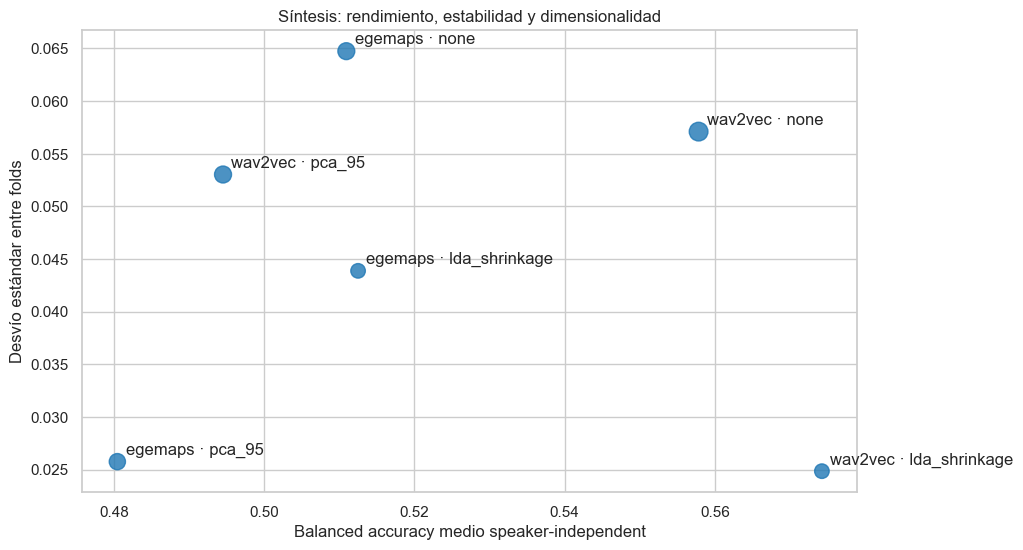

,representation,refinement,balanced_accuracy_mean,balanced_accuracy_std,n_features
3,wav2vec,lda_shrinkage,0.574,0.025,7.0
4,wav2vec,none,0.558,0.057,768.0
0,egemaps,lda_shrinkage,0.512,0.044,7.0
1,egemaps,none,0.511,0.065,88.0
5,wav2vec,pca_95,0.495,0.053,96.2
2,egemaps,pca_95,0.480,0.026,40.2


In [11]:
if not cv_results.empty:
    final = cv_results.query(
        "protocol == @PROTOCOL and target == @PRIMARY_TARGET and "
        "model == 'logistic_regression' and "
        "refinement in ['none', 'pca_95', 'lda_shrinkage']"
    ).copy()

    if not final.empty:
        final_summary = (
            final.groupby(["representation", "refinement"], observed=True)
            .agg(
                balanced_accuracy_mean=("balanced_accuracy", "mean"),
                balanced_accuracy_std=("balanced_accuracy", "std"),
                n_features=("n_features", "mean"),
            )
            .reset_index()
        )

        fig, ax = plt.subplots(figsize=(10, 6))
        sizes = 80 + 35 * np.log10(final_summary["n_features"].clip(lower=1))
        ax.scatter(final_summary["balanced_accuracy_mean"], final_summary["balanced_accuracy_std"], s=sizes, alpha=0.8)
        for _, row in final_summary.iterrows():
            ax.annotate(
                f"{row['representation']} · {row['refinement']}",
                (row["balanced_accuracy_mean"], row["balanced_accuracy_std"]),
                xytext=(6, 5),
                textcoords="offset points",
            )
        ax.set_xlabel("Balanced accuracy medio speaker-independent")
        ax.set_ylabel("Desvío estándar entre folds")
        ax.set_title("Síntesis: rendimiento, estabilidad y dimensionalidad")
        plt.show()

        display(
            final_summary.sort_values(
                ["balanced_accuracy_mean", "balanced_accuracy_std"],
                ascending=[False, True],
            ).round(3)
        )

### Conclusión del notebook

La inestabilidad no se debe principalmente a una falta de separabilidad lineal del embedding global, sino a que el mean pooling mezcla información temporal emocionalmente relevante y conserva variaciones dependientes del hablante. Incorporar estadísticas temporales, selección de capas y atención ligera debería mejorar la robustez antes de recurrir a modelos generativos o arquitecturas profundas.